Базовый осмотр

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from PIL.ImageFont import truetype

df = pd.read_csv('../data/raw/moscow_apartments.csv')

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
print(pd.DataFrame({'count': missing, 'pct': missing_pct.round(2)})[missing > 0])
print(f"\nDuplicates: {df.duplicated().sum()}")

Shape: (22676, 12)

Dtypes:
Price               float64
Apartment type          str
Metro station           str
Minutes to metro    float64
Region                  str
Number of rooms     float64
Area                float64
Living area         float64
Kitchen area        float64
Floor               float64
Number of floors      int64
Renovation              str
dtype: object

Missing values:
Empty DataFrame
Columns: [count, pct]
Index: []

Duplicates: 1835


Числовые признаки

In [17]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

stats_df = df[num_cols].agg(['mean','median','std','min','max',lambda x:x.quantile(0.25),lambda x:x.quantile(0.75),'skew','kurt'])

stats_df.index = ['mean', 'median', 'std', 'min', 'max', 'Q1', 'Q3', 'skewness', 'kurtosis']
print("\nNumeric stats:")
print(stats_df.round(3).T)

for col in num_cols:
    skew = df[col].skew()
    if abs(skew) > 1:
        print(f'{col}: HIGH skewness = {skew:.3f}')



Numeric stats:
                          mean      median           std        min  \
Price             3.612132e+07  11343200.0  8.282561e+07  1150000.0   
Minutes to metro  1.188900e+01        11.0  6.204000e+00        0.0   
Number of rooms   2.043000e+00         2.0  1.524000e+00        0.0   
Area              7.196700e+01        53.3  6.836900e+01        6.0   
Living area       3.851800e+01        28.5  3.812400e+01        2.0   
Kitchen area      1.259400e+01        10.6  7.728000e+00        1.0   
Floor             9.190000e+00         8.0  7.550000e+00        1.0   
Number of floors  1.655600e+01        16.0  9.779000e+00        1.0   

                           max         Q1           Q3  skewness  kurtosis  
Price             2.455020e+09  7068116.0  24799247.50     7.243    92.943  
Minutes to metro  6.000000e+01        7.0        15.00     1.462     5.908  
Number of rooms   1.200000e+01        1.0         3.00     0.702     0.311  
Area              1.117000e+03      

Вывод: все числовые колонки имеют сильное смещение в правую сторону и экстремально тяжелые хвосты которые прийдется сжимать

Категориальные признаки

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(normalize=True).mul(100).round(1).to_string())




Apartment type: 2 unique values
Apartment type
Secondary       58.0
New building    42.0

Metro station: 547 unique values
Metro station
Красногвардейская                11.9
Депо                              7.3
Братиславская                     5.1
Котельники                        4.3
Жулебино                          3.2
Зябликово                         3.2
Битца                             1.6
 Опалиха                          1.3
Каширская                         1.3
Домодедовская                     1.2
ЗИЛ                               0.9
Варшавская                        0.9
Алма-Атинская                     0.7
Аминьевская                       0.7
Некрасовка                        0.6
 Спортивная                       0.6
Перерва                           0.6
Аннино                            0.6
Отрадное                          0.5
Панфиловская                      0.5
Народное Ополчение                0.5
Минская                           0.5
 Павшино                  

C:\Users\user\AppData\Local\Temp\ipykernel_14248\822872190.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


Аномалии

In [19]:
print(f'Больше 120 минут до метро : {(df['Minutes to metro'] > 120).sum()} строк')
print(f'Number of floors > 90: {(df['Number of floors'] > 90).sum()}')
print(f'price per m^2 < 150_000: {((df['Price']/df['Area']) < 150000 ).sum()} ')
print(f'price per m^2 > 1_500_000: {((df['Price']/df['Area']) > 1500000 ).sum()} ')
print(f'Number of rooms = 0 : {(df['Number of rooms'] == 0).sum()}')


Больше 120 минут до метро : 0 строк
Number of floors > 90: 11
price per m^2 < 150_000: 4127 
price per m^2 > 1_500_000: 334 
Number of rooms = 0 : 3731


Вывод: 1.минуты до метро без аномалий
2.насчет количества этажей я не нашел информации что существуют жилые дома выше 90 этажей возможно непрвильные данные
3.что касается цены за кв.м меньше 150т может быть если указаны данные за комнату или долю стоит еще раз проверить и если что удалить
4.цены больше 1.5млн за кв метр вполне ожидаемое количество скорее всего эта характеристика в норме
5.самое важное существует 3731 квартир где число комнат равно 0, возможно это студии это стоит проверить

# Удаление выбросов

In [20]:
studio_check = df[df['Number of rooms'] == 0]
print(studio_check[['Area','Price','Number of rooms']].describe())

              Area         Price  Number of rooms
count  3731.000000  3.731000e+03           3731.0
mean     33.420976  1.365475e+07              0.0
std      52.635665  5.295803e+07              0.0
min       6.000000  1.150000e+06              0.0
25%      18.500000  4.105640e+06              0.0
50%      23.890000  5.450000e+06              0.0
75%      28.230000  8.700000e+06              0.0
max    1117.000000  1.732171e+09              0.0


In [21]:

initial_count = len(df)
cleaning_log = []

def log_step(step_name, before, after):
    removed = before - after
    cleaning_log.append({
        'step': step_name,
        'before': before,
        'after': after,
        'removed': removed
    })
    print(f"[{step_name}] было: {before}, стало: {after}, удалено: {removed}")


before = len(df)
df = df[df['Living area'] <= df['Area']].copy()
log_step("Living area > Area", before, len(df))

before = len(df)
df = df[(df['Living area'] + df['Kitchen area']) <= df['Area']].copy()
log_step("Living + Kitchen > Area", before, len(df))

before = len(df)
df = df[df['Floor'] <= df['Number of floors']].copy()
log_step("Floor > Number of floors", before, len(df))

studios_mask = df['Number of rooms'] == 0
Q1 = df.loc[studios_mask, 'Area'].quantile(0.25)
Q3 = df.loc[studios_mask, 'Area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)
mask_bad_studios = studios_mask & ((df['Area'] < lower_bound) | (df['Area'] > upper_bound))
df = df[~mask_bad_studios].copy()
log_step(f"Студии вне диапазона [{lower_bound:.1f}, {upper_bound:.1f}] м²", before, len(df))


def remove_outliers_percentile(df, column, lower_pct=0.01, upper_pct=0.99):
    lower = df[column].quantile(lower_pct)
    upper = df[column].quantile(upper_pct)
    mask = (df[column] >= lower) & (df[column] <= upper)
    return mask, lower, upper

for col in ['Price', 'Area', 'Living area', 'Kitchen area']:
    before = len(df)
    mask, lower, upper = remove_outliers_percentile(df, col)
    df = df[mask].copy()
    log_step(f"{col} вне [{lower:.0f}, {upper:.0f}]", before, len(df))


final_count = len(df)
print(f"\nИтого: {initial_count} → {final_count} (удалено {initial_count - final_count}, "
      f"{(initial_count - final_count) / initial_count * 100:.1f}%)")


import os

project_root = os.path.dirname(os.getcwd())
output_dir = os.path.join(project_root, 'data', 'interim')

os.makedirs(output_dir, exist_ok=True)
df.to_csv(os.path.join(output_dir, 'apartments_cleaned.csv'), index=False)

log_df = pd.DataFrame(cleaning_log)
print("\nЛог очистки:")
print(log_df.to_string(index=False))

[Living area > Area] было: 22676, стало: 22676, удалено: 0
[Living + Kitchen > Area] было: 22676, стало: 21599, удалено: 1077
[Floor > Number of floors] было: 21599, стало: 19949, удалено: 1650
[Студии вне диапазона [11.0, 42.5] м²] было: 19949, стало: 19515, удалено: 434
[Price вне [2896122, 400000000]] было: 19515, стало: 19131, удалено: 384
[Area вне [17, 330]] было: 19131, стало: 18750, удалено: 381
[Living area вне [9, 157]] было: 18750, стало: 18399, удалено: 351
[Kitchen area вне [3, 35]] было: 18399, стало: 18091, удалено: 308

Итого: 22676 → 18091 (удалено 4585, 20.2%)

Лог очистки:
                                step  before  after  removed
                  Living area > Area   22676  22676        0
             Living + Kitchen > Area   22676  21599     1077
            Floor > Number of floors   21599  19949     1650
Студии вне диапазона [11.0, 42.5] м²   19949  19515      434
      Price вне [2896122, 400000000]   19515  19131      384
                  Area вне [17, 330

# Визуализация

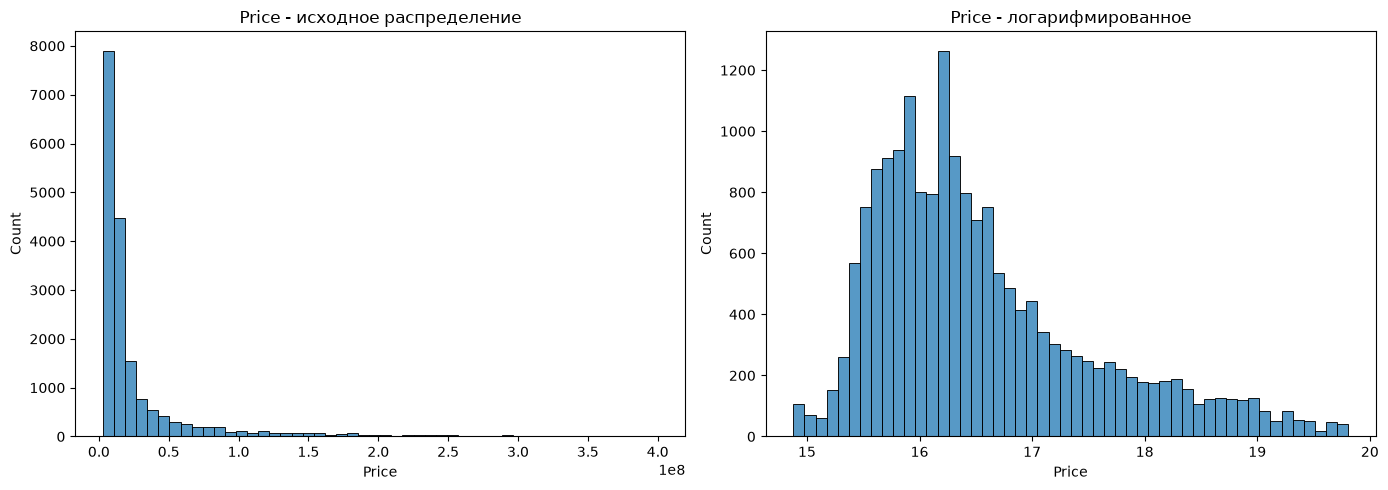

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=50, ax=axes[0])
axes[0].set_title('Price - исходное распределение')

sns.histplot(np.log1p(df['Price']), bins=50, ax=axes[1])
axes[1].set_title('Price - логарифмированное')

plt.tight_layout()
plt.show()

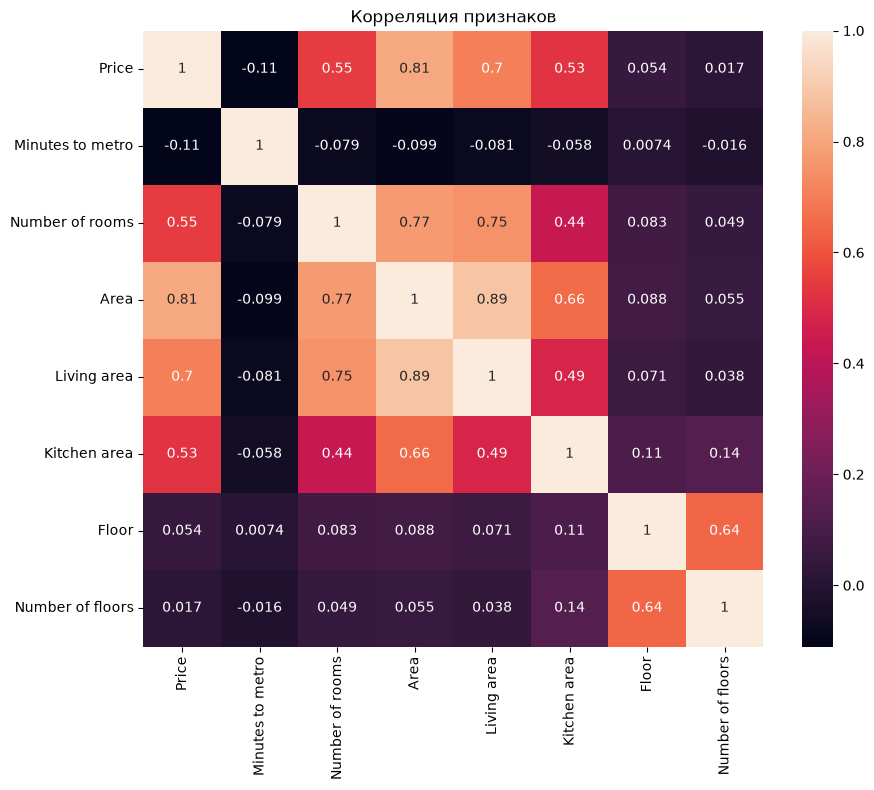

In [25]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True)
plt.title('Корреляция признаков')
plt.show()

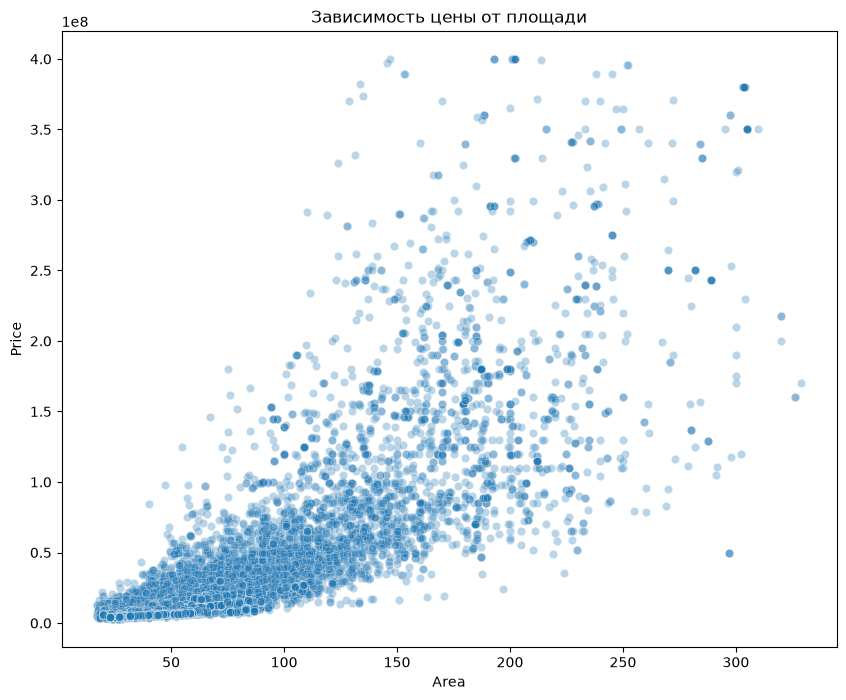

In [31]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Area',y='Price',alpha=0.3)
plt.title('Зависимость цены от площади')
plt.show()

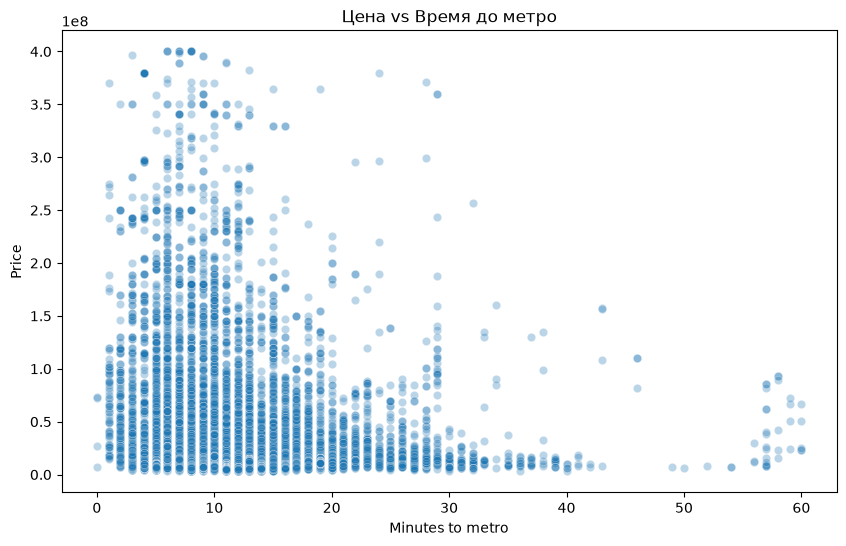

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Minutes to metro', y='Price', alpha=0.3)
plt.title('Цена vs Время до метро')
plt.show()

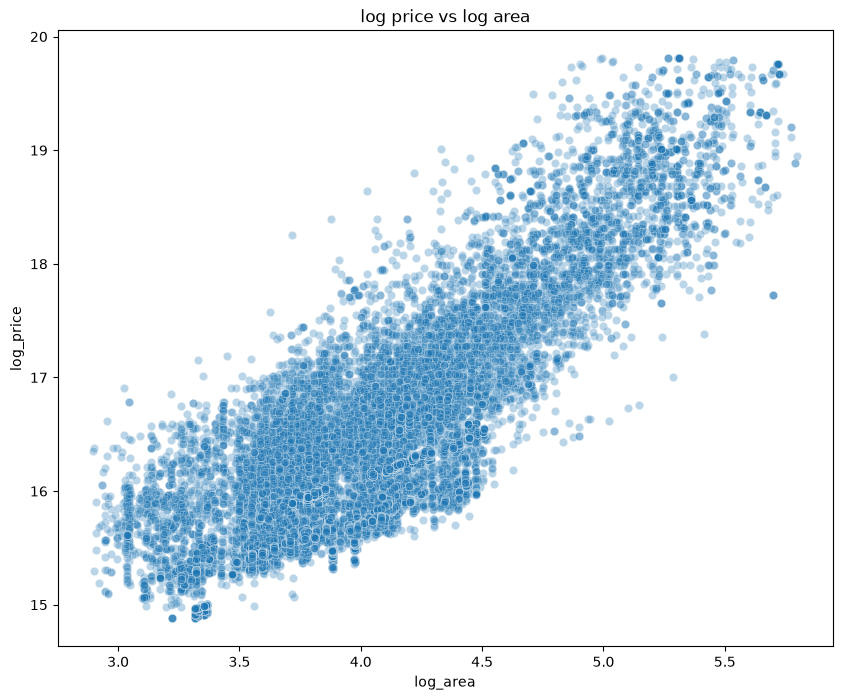

In [33]:
df['log_price'] = np.log1p(df['Price'])
df['log_area'] = np.log1p(df['Area'])

plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='log_area',y='log_price',alpha=0.3)
plt.title('log price vs log area')
plt.show()

После логарифмироваиния связь стала более линейной

C:\Users\user\AppData\Local\Temp\ipykernel_14248\117250020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bottom['median'], y=top_bottom.index, palette='coolwarm')


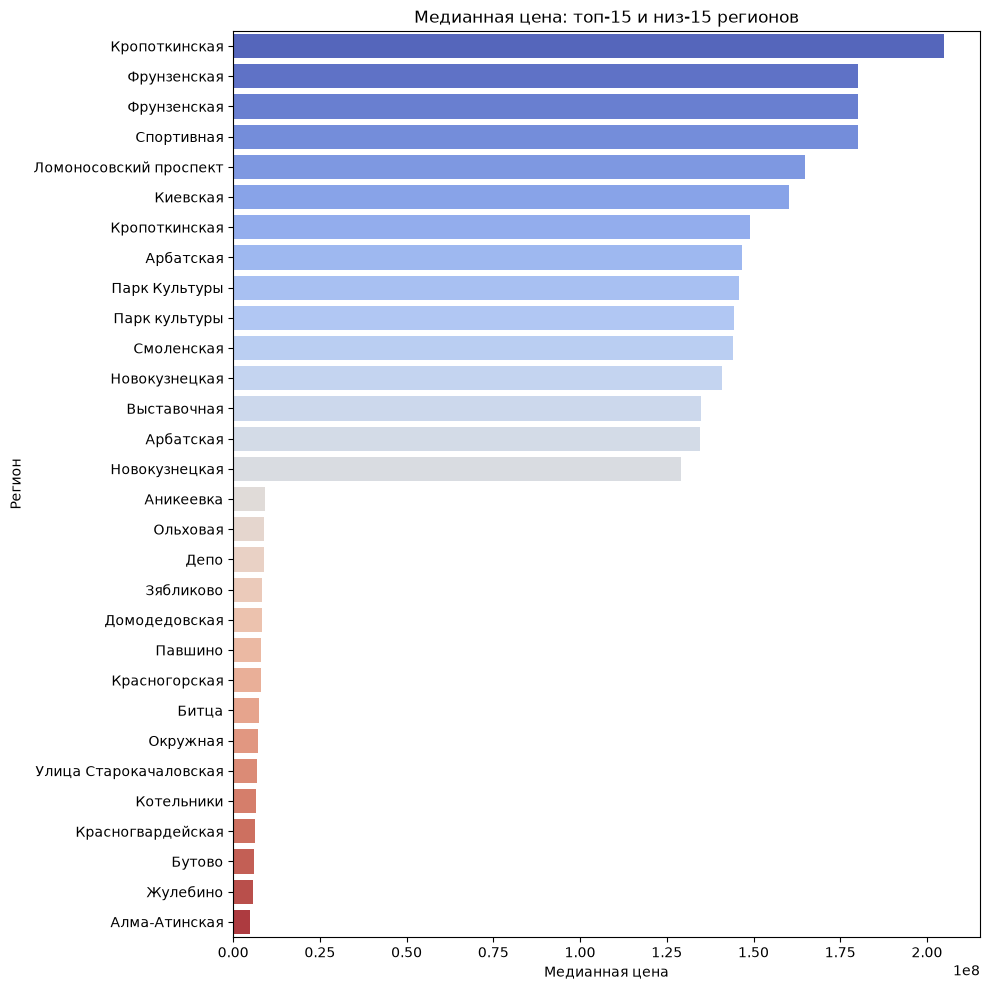

In [36]:
# Топ-15 и низ-15 регионов по медианной цене (с фильтром на минимальное число объектов)
region_stats = df.groupby('Metro station')['Price'].agg(['median', 'count']).sort_values('median', ascending=False)
region_stats_filtered = region_stats[region_stats['count'] >= 20]

top_bottom = pd.concat([
    region_stats_filtered.head(15),
    region_stats_filtered.tail(15)
])

plt.figure(figsize=(10, 10))
sns.barplot(x=top_bottom['median'], y=top_bottom.index, palette='coolwarm')
plt.title('Медианная цена: топ-15 и низ-15 регионов')
plt.xlabel('Медианная цена')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()

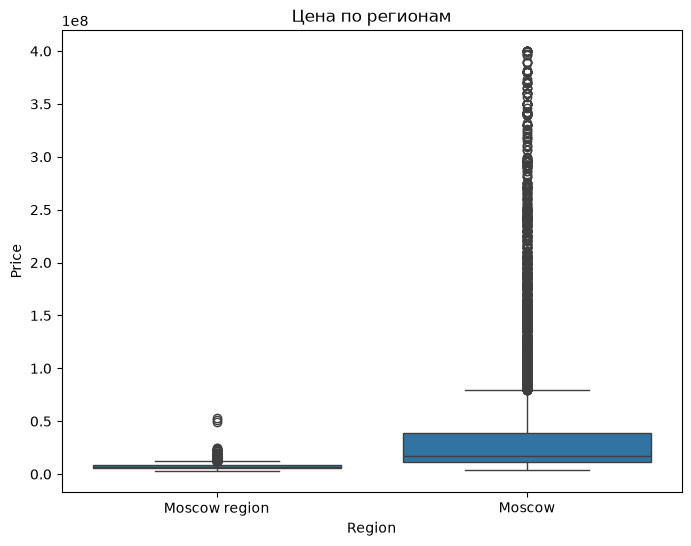

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Region', y='Price')
plt.title('Цена по регионам')
plt.show()

In [38]:
PROJECT_ROOT = r'C:\Users\user\moscow_apartments'  # или через os.path
df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'interim', 'apartments_cleaned.csv'))

df['living_area_ratio'] = df['Living area'] / df['Area']

df = df.drop(columns=['Living area'])

# Проверка
print(df[['Area', 'living_area_ratio']].describe())
print(f"\nПропуски в living_area_ratio: {df['living_area_ratio'].isnull().sum()}")

df.to_csv(os.path.join(PROJECT_ROOT, 'data', 'interim', 'apartments_cleaned.csv'), index=False)
print("\nФайл обновлён")

               Area  living_area_ratio
count  18091.000000       18091.000000
mean      67.514081           0.537300
std       44.240948           0.112082
min       17.100000           0.050420
25%       39.840000           0.500000
50%       54.700000           0.542857
75%       77.000000           0.600000
max      329.000000           0.936842

Пропуски в living_area_ratio: 0

Файл обновлён


## Итоги EDA

### Целевая переменная (Price)
- Распределение цены сильно скошено вправо (skewness ≈ 7.2) — присутствуют
  экстремальные выбросы (максимум более 2 млрд при медиане ~11.3 млн)
- Логарифмирование (`log1p`) существенно нормализует распределение —
  планируется использовать `log_price` как целевую переменную для линейных моделей

### Очистка данных
- Удалены записи с логическими противоречиями: `Living area > Area`,
  `Kitchen + Living area > Area`, `Floor > Number of floors`
- Обработаны квартиры с `rooms == 0` (студии): подтверждено, что основная
  масса — реальные студии (18.5–28 м²), выбросы (6 м² и 1117 м²) удалены
  через IQR-метод в пределах группы
- Применена перцентильная фильтрация (1–99%) по `Price`, `Area`,
  `Living area`, `Kitchen area` для удаления оставшихся выбросов


### Зависимость цены от признаков
- **Площадь**: обнаружена нелинейная зависимость `Price` от `Area` —
  цена растёт непропорционально быстрее для больших квартир. Это мотивирует
  выбор моделей на основе деревьев решений (CatBoost, Random Forest) как
  основных, наряду с логарифмической трансформацией для baseline линейной модели
- **Метро**: расстояние до метро (`Minutes to metro`) показывает
  ожидаемую обратную связь с ценой
- **Комнаты**: цена ожидаемо растёт с количеством комнат, разброс внутри
  каждой категории значителен
- **Регион**: два региона показывают заметно различающиеся ценовые уровни
- **Станции метро**: высокая кардинальность (500+ уникальных значений);
  топ- и низ-станции по медианной цене показывают существенный разброс
  внутри города

### Мультиколлинеарность
- Обнаружена сильная корреляция между `Area` и `Living area` (r = 0.89)
- Решение: `Living area` заменена на производный признак
  `living_area_ratio` (Living area / Area), сохраняющий уникальную
  информацию без дублирования размера квартиры; `Area` оставлена как есть

### Выводы для дальнейшей работы
- Целевая переменная: `log_price` для линейных моделей, `Price` — можно
  использовать напрямую для CatBoost (менее чувствителен к скошенности)
- Основная модель: CatBoost (нативная поддержка категориальных признаков
  высокой кардинальности, устойчивость к нелинейностям и мультиколлинеарности)
- Baseline: линейная регрессия на логарифмированных `Price` и `Area`
- Признак `metro_station` требует осторожного кодирования (target encoding
  с регуляризацией или прямая передача в CatBoost как категориальный)